Mata Kuliah FSD

Kelas A

Anggota kelompok:

  1. Muhammad Wahyu Ramadhani - 24523110

  2. Handiva Rahmawan Diachmadja - 24523112

1. Persiapan Data

Data prediksi harga rumah berdasarkan luas


In [ ]:
import numpy as np
import pandas as pd

data = {
    'luas_rumah': [35, 45, 50, 60, 75, 80, 90, 100, 110, 120,
                   130, 140, 150, 170, 180, 185],
    'harga_rumah': [150, 175, 200, 250, 275, 325, 350, 400, 450, 480,
                    520, 550, 600, 750, 825, 980]
}


df = pd.DataFrame(data)

print("Dataset Harga Rumah:")
print(df)
print(f"\nJumlah data: {len(df)} baris")
print(f"Fitur: {df.columns.tolist()}")

Dataset Harga Rumah:
    luas_rumah  harga_rumah
0           35          150
1           45          175
2           50          200
3           60          250
4           75          275
5           80          325
6           90          350
7          100          400
8          110          450
9          120          480
10         130          520
11         140          550
12         150          600
13         170          750
14         180          825
15         185          980

Jumlah data: 16 baris
Fitur: ['luas_rumah', 'harga_rumah']


2. Eksplorasi Data (EDA)

- Tampilkan beberapa baris data.
- Buat visualisasi hubungan antara variabel independen dan dependen (gunakan matplotlib atau seaborn).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("5 Baris Pertama Dataset:")
print(df.head())

5 Baris Pertama Dataset:
   luas_rumah  harga_rumah
0          35          150
1          45          175
2          50          200
3          60          250
4          75          275


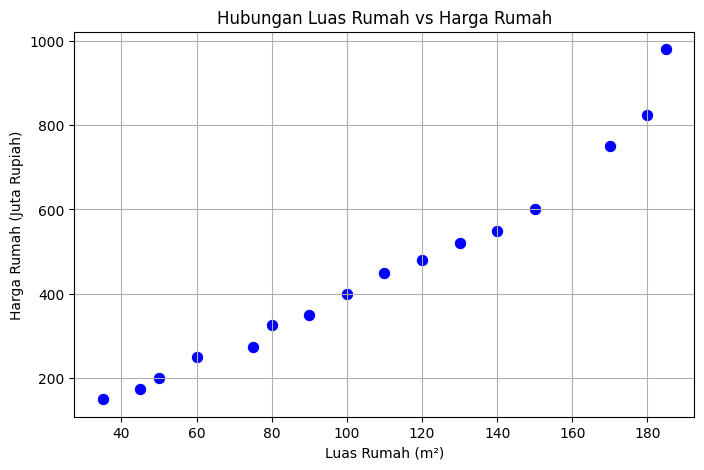

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='luas_rumah', y='harga_rumah', data=df, color='blue', s=80)

plt.title('Hubungan Luas Rumah vs Harga Rumah')
plt.xlabel('Luas Rumah (m²)')
plt.ylabel('Harga Rumah (Juta Rupiah)')
plt.grid(True)
plt.show()

3. Pembangunan Model
- Gunakan LinearRegression dari sklearn.linear_model.
- Pisahkan data menjadi training dan testing set.
- Latih model dengan data training.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['luas_rumah']]
y = df['harga_rumah']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 12
Jumlah data testing: 4


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!


4. Evaluasi Model
- Lakukan prediksi pada data testing.
- Tampilkan nilai koefisien regresi (slope & intercept).
- Hitung dan tampilkan R2 Score atau Mean Squared Error (MSE).

In [ ]:
y_pred = model.predict(X_test)

print(f"Slope (Koefisien): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Slope (Koefisien): 5.07
Intercept: -98.82


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

R² Score: 0.9739
Mean Squared Error (MSE): 1926.25


5. Visualisasi Hasil
- Tampilkan plot garis regresi dan titik data aktual.
- Bandingkan hasil prediksi dengan nilai aktual.

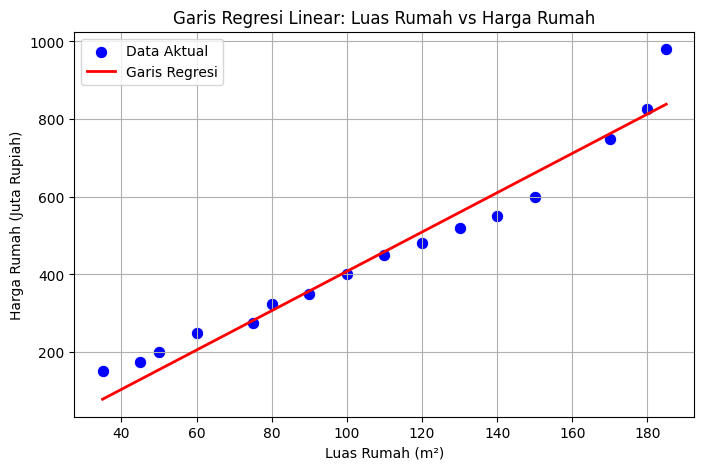

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='luas_rumah', y='harga_rumah', data=df,
                color='blue', s=80, label='Data Aktual')


plt.plot(df['luas_rumah'], model.predict(df[['luas_rumah']]),
         color='red', linewidth=2, label='Garis Regresi')

plt.title('Garis Regresi Linear: Luas Rumah vs Harga Rumah')
plt.xlabel('Luas Rumah (m²)')
plt.ylabel('Harga Rumah (Juta Rupiah)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
hasil = pd.DataFrame({
    'Luas Rumah': X_test['luas_rumah'].values,
    'Harga Aktual': y_test.values,
    'Harga Prediksi': y_pred.round(2)
})

print("Perbandingan Harga Aktual vs Prediksi:")
print(hasil)

Perbandingan Harga Aktual vs Prediksi:
   Luas Rumah  Harga Aktual  Harga Prediksi
0          35           150           78.48
1          45           175          129.14
2          80           325          306.45
3         180           825          813.03


6. Analisis dan Kesimpulan
  - Jelaskan interpretasi hasil model:
    - Apa makna dari slope dan intercept?
      - Slope (5.07): Setiap luas rumah bertambah 1 m² maka harga rumah naik sebesar 5.07 juta rupiah.
      - Intercept (-98.82): Nilai ini menunjukkan harga saat luas rumah = 0 adalah -98.82 juta rupiah.
    - Seberapa baik model memprediksi data?
      - R² Score = 0.9739 artinya model bisa menjelaskan sekitar 97.39% hubungan antara luas rumah dan harga rumah.
      - MSE = 1926.25 artinya rata-rata selisih prediksi dengan harga aslinya sekitar 43 juta rupiah.
    - Apakah ada indikasi overfitting atau underfitting?
      -  Model ini tidak overfitting maupun underfitting, karena R² nilainya tinggi dan hasil prediksinya mendekati data aslinya.

  - Kesimpulan Akhir

     Secara keseluruhan model Linear Regression yang di buat berhasil memprediksi harga rumah berdasarkan luas rumah. Dari hasil analisis terlihat bahwa semakin luas rumahnya maka semakin tinggi harganya.